# Treasuries


> **Setting — September 30, 2020.** This snapshot is the peak of the COVID-era surge in Treasury **bill** issuance: bills reached ~25% of marketable debt as Treasury funded emergency stimulus with short-term paper, and new coupon issues carried near-zero rates. As you build each view below, **compare it to the current (2026) picture in the Treasury Debt discussion** — how do the bill share, coupon levels, and total debt outstanding differ, and why?

***

# Data

Use the data file `data/treasury_quotes_2020-09-30.xlsx`.

***

# 1. Treasury Debt Composition

### Data
Use the data in the `quotes` tab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

filepath = 'data/treasury_quotes_2020-09-30.xlsx'
data = pd.read_excel(filepath, sheet_name='quotes').set_index('KYTREASNO')

print(data.shape)
data.head()

(415, 16)


,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,public size,duration
KYTREASNO,,,,,,,,,,,,,,,,
207503,bill,2020-09-30,2020-04-02,2020-10-01,0.002738,0.994524,0.000,99.999853,99.999881,99.999867,0.000000,99.999867,0.000487,1.747520e+11,NaN,0.002740
207521,bill,2020-09-30,2020-05-05,2020-10-06,0.016427,0.967146,0.000,99.999000,99.999167,99.999083,0.000000,99.999083,0.000558,1.363870e+11,NaN,0.016438
207427,bill,2020-09-30,2019-10-10,2020-10-08,0.021903,0.956194,0.000,99.998778,99.999000,99.998889,0.000000,99.998889,0.000507,2.066680e+11,NaN,0.021918
207535,bill,2020-09-30,2020-05-12,2020-10-13,0.035592,0.928816,0.000,99.997653,99.998014,99.997833,0.000000,99.997833,0.000609,1.352900e+11,NaN,0.035616
207146,note,2020-09-30,2017-10-15,2020-10-15,0.041068,0.918033,1.625,100.039062,100.078125,100.058594,0.745902,100.804495,0.001934,2.399600e+10,2.091800e+10,0.041096


## 1.1
Plot the total amount of outstanding debt maturing at each date

* Do this for `total size`, as that is listed for T-bills.
* (You could also examine `public size`, but that will exclude T-bills.)

Tip: `.pivot_table()` may be useful.

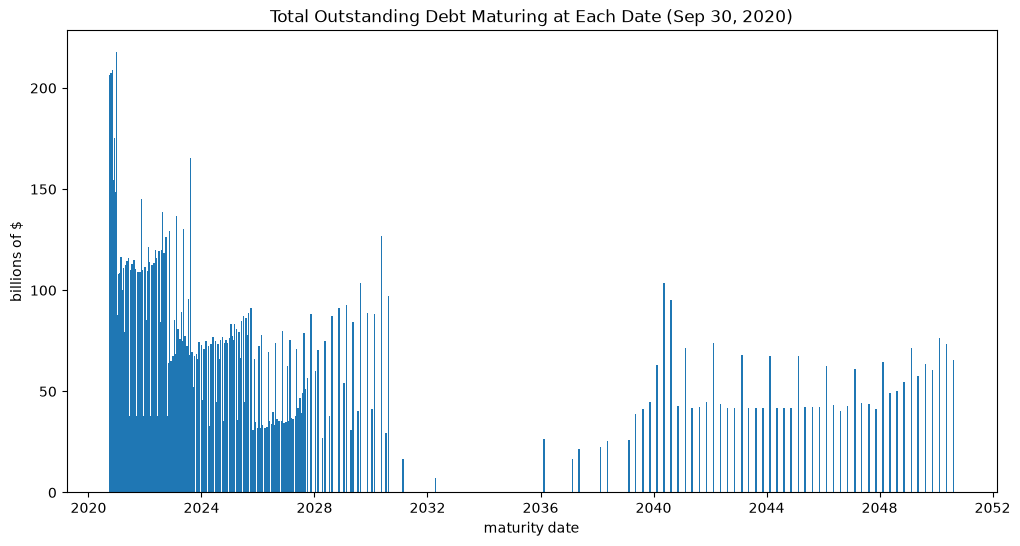

In [2]:
# sum total size across issues maturing on each date, in billions
maturing = data.pivot_table(values='total size', index='maturity date', aggfunc='sum') / 1e9

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(maturing.index, maturing['total size'], width=20)
ax.set_title('Total Outstanding Debt Maturing at Each Date (Sep 30, 2020)')
ax.set_xlabel('maturity date')
ax.set_ylabel('billions of $')
plt.show()

## 1.2
Plot the amount of outstanding debt maturing at each date, segmented by bonds, notes, TIPS.

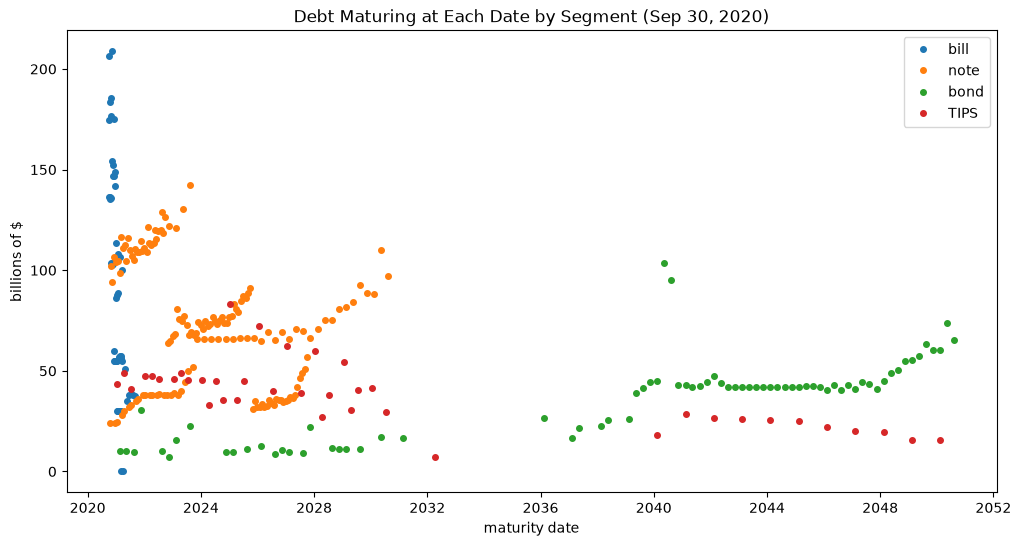

In [3]:
# group TIPS notes and TIPS bonds together
data['category'] = data['type'].replace({'TIPS note': 'TIPS', 'TIPS bond': 'TIPS'})

seg = data.pivot_table(values='total size', index='maturity date', columns='category', aggfunc='sum') / 1e9

fig, ax = plt.subplots(figsize=(12, 6))
for cat in ['bill', 'note', 'bond', 'TIPS']:
    ax.plot(seg.index, seg[cat], marker='o', linestyle='', markersize=4, label=cat)
ax.set_title('Debt Maturing at Each Date by Segment (Sep 30, 2020)')
ax.set_xlabel('maturity date')
ax.set_ylabel('billions of $')
ax.legend()
plt.show()

## 1.3
Report the total outstanding debt (summed over all maturity dates,) segmented by bonds, notes, TIPS.

In [4]:
# total outstanding by segment, in billions
totals = data.pivot_table(values='total size', index='category', aggfunc='sum') / 1e9
totals = totals.loc[['bill', 'note', 'bond', 'TIPS']].round(1)
totals.columns = ['total size (billions)']

print(f"total outstanding: {totals['total size (billions)'].sum():,.1f} billion")
totals

total outstanding: 19,889.3 billion


,total size (billions)
category,
bill,5028.9
note,10663.7
bond,2673.5
TIPS,1523.2


## 1.4
Make a pie chart of this total number (reported in 1.3.)

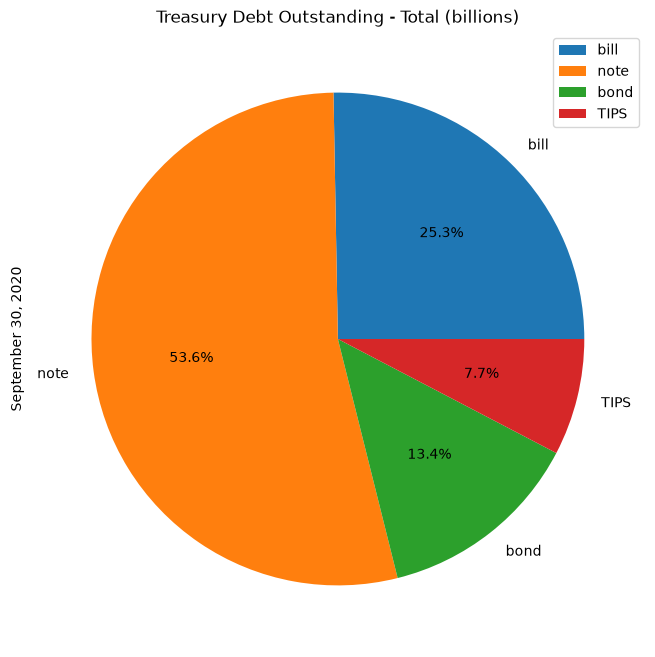

In [5]:
totals.plot.pie(y='total size (billions)', figsize=(8, 8), autopct='%.1f%%',
                title='Treasury Debt Outstanding - Total (billions)', ylabel='September 30, 2020')
plt.show()

## 1.5

Calculate the time-to-maturity (relative to the quoted date) for each issue.

Report the summary statistics of these time-to-maturities. 

Consider using `.describe()`

In [6]:
# years from the quote date to each issue's maturity date
data['time to maturity'] = (data['maturity date'] - data['quote date']).dt.days / 365.25

data['time to maturity'].describe()

count    415.000000
mean       6.141092
std        7.987937
min        0.002738
25%        0.895277
50%        2.915811
75%        6.599589
max       29.872690
Name: time to maturity, dtype: float64

***

### Comparison to the current (2026) picture

Total debt here is about $19.9 trillion vs about $30.7 trillion in the 2026 discussion, so it grew by more than half in under six years. Bills are about 25% of the total in this snapshot, the covid peak, while in 2026 they are closer to 22%. New coupon issues in late 2020 paid close to zero since the Fed was at the zero lower bound, while new issues in 2026 pay several percent, which makes the debt much more expensive to service.